In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [4]:
# Loading the dataset
data = pd.read_csv("housing.csv")
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
# Understanding the dataset
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
# Handling catecogrical data
data = pd.get_dummies(data, drop_first=True)
data.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [7]:
# Features and target variable
x = data[['area', 'bedrooms', 'bathrooms']]
y = data['price']

In [8]:
# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [ ]:
# Model Training
model = LinearRegression()
model.fit(x_train, y_train)

In [ ]:
# Predictions
predictions = model.predict(x_test)

In [ ]:
# Evaluation
print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("R2 Score:", metrics.r2_score(y_test, predictions))

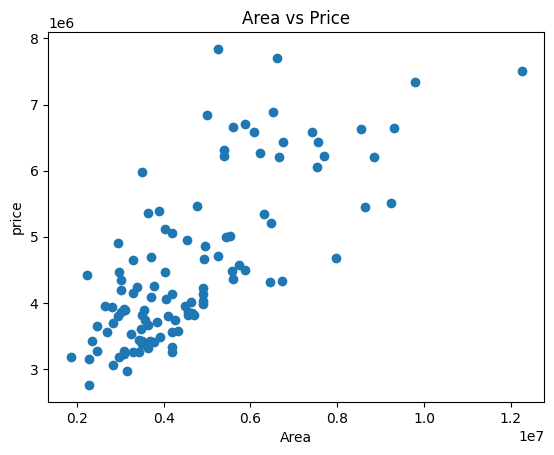

In [20]:
# plotting the actual vs predicted values
plt.scatter(y_test, predictions)
plt.xlabel("Area")
plt.ylabel("price")
plt.title("Area vs Price")
plt.show()

##### Random Forest Regressor model uused here perfroms worse than the linear regression model as the dataset has a linear relationship between features and target, which makes linear regression more suitable. Additionally, Random Forest may require hyper parameters tuning and larger datasets to perform optimally

In [ ]:
# Better Model 
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

# Linear Regression Results
print("----- Linear Regression -----")
print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("R2:", metrics.r2_score(y_test, predictions))


# Random Forest Model
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

rf_preds = rf.predict(x_test)

print("\n----- Random Forest -----")
print("MAE:", metrics.mean_absolute_error(y_test, rf_preds))
print("R2:", metrics.r2_score(y_test, rf_preds))

----- Linear Regression -----
MAE: 964267.9611022732
R2: 0.5395454163650709

----- Random Forest -----
MAE: 1058472.3063327346
R2: 0.3258550186900714


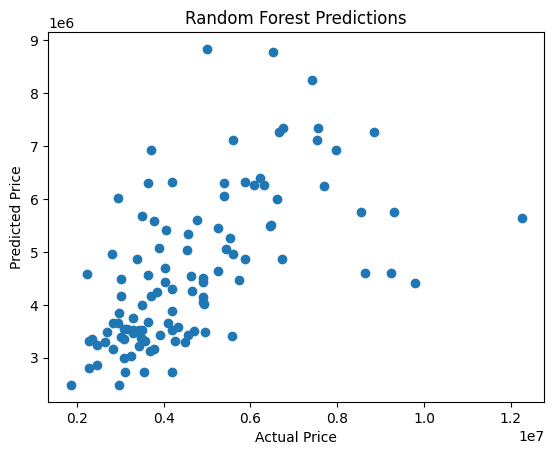

In [23]:
# Random Forest Predictions plot
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Predictions")
plt.show()

In [25]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(x_train, y_train)

rf_preds = rf.predict(x_test)

print("Improved RF MAE:", metrics.mean_absolute_error(y_test, rf_preds))
print("Improved RF R2:", metrics.r2_score(y_test, rf_preds))

Improved RF MAE: 1028706.3590667915
Improved RF R2: 0.35381257171347547
